In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx

from non_parametric_pro.density import ProParameters, pro_logdensity_grad_fn
from non_parametric_pro.ula import pro_ula

from blackjax.util import run_inference_algorithm

/Users/callum/Projects/non-parametric-pro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
key = jr.key(0)

n = 20
noise = 0.3

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x, y=y)

xtest = jnp.linspace(-3.5, 3.5, 500).reshape(-1, 1)
ytest = f(xtest)

/Users/callum/Projects/non-parametric-pro/.venv/lib/python3.12/site-packages/gpjax/dataset.py:43: UserWarning: X is not of type float64. Got X.dtype=float32. This may lead to numerical instability. 
  _check_precision(self.X, self.y)
/Users/callum/Projects/non-parametric-pro/.venv/lib/python3.12/site-packages/gpjax/dataset.py:43: UserWarning: y is not of type float64.Got y.dtype=float32. This may lead to numerical instability.
  _check_precision(self.X, self.y)


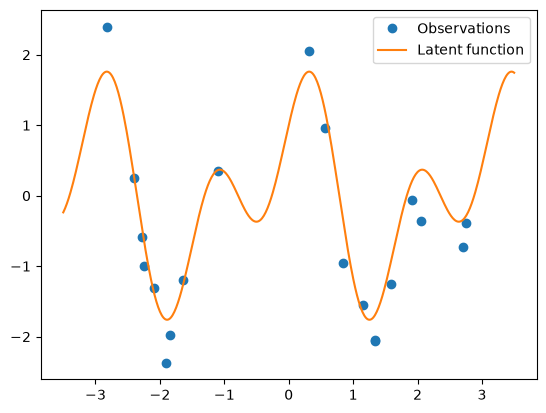

In [3]:
fig, ax = plt.subplots()
ax.plot(x, y, "o", label="Observations")
ax.plot(xtest, ytest, label="Latent function")
ax.legend(loc="best")
plt.show()

In [45]:
n = 20  # number of observations
m = 20   # number of basis functions
j = 4   # number of particles

k = gpx.kernels.RBF()
basis = k.gram(x).as_matrix()
position = jr.normal(key, (m, j))

params = ProParameters(
    y=y,
    basis=basis,
    step_size=1e-4,
    nu=0.1,
    alpha=1.0,
    tolerance=1e-200,
    jitter=1e-5,
)

ula = pro_ula(pro_logdensity_grad_fn, params)


In [48]:
out, history = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=ula,
    num_steps=1000,
    initial_position=position,
    progress_bar=True
)

<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:00&lt;?]</div>

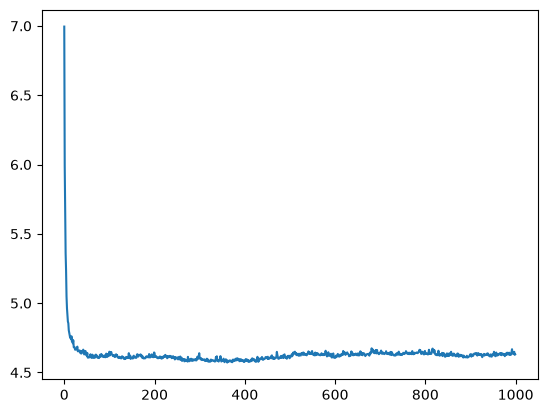

In [50]:
score_history = history[1].score

plt.plot(jnp.log(-score_history))
plt.show()